# Task 3: Energy Consumption Time Series Forecasting
# Problem Statement & Objective

* **Problem Statement:** Household energy consumption is highly volatile and depends on time-based patterns. Managing power grids requires accurate short-term forecasts to prevent outages and optimize distribution.
  
* **Objective:** To forecast short-term household energy usage by engineering time-based features and comparing the performance of **ARIMA,** **Prophet,** and **XGBoost** models.

# Dataset Description & Loading
The household power consumption dataset is imported. To facilitate time-series analysis,the 'Date' and 'Time' columns are merged into a standard datetime index.

In [1]:
import pandas as pd

file_path = 'household_power_consumption.csv'
df = pd.read_csv(file_path, sep=';', low_memory=False, na_values=['?'])

df.columns = df.columns.str.strip()

if 'Date' in df.columns and 'Time' in df.columns:
    df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['dt'])
    df.set_index('dt', inplace=True)
    
    df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
    df_hourly = df['Global_active_power'].resample('H').mean().ffill()
    
    print(" Data resampled to Hourly frequency.")
    print(df_hourly.head())
else:
    print( df.columns.tolist()) 

['Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3']


In [2]:
import pandas as pd
import numpy as np

# Load data and fix column names
df = pd.read_csv('household_power_consumption.csv', sep=',', low_memory=False, na_values=['?'])
df.columns = df.columns.str.strip()

# Create Datetime Index
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('dt', inplace=True)
print("Step 1 Done: Data Loaded.") 

Step 1 Done: Data Loaded.


# Feature Engineering
The objective of this step is to transform the raw timestamp into meaningful numerical features that a machine learning model can process.
* **Approach:** > * Since energy consumption follows strong cyclical patterns (daily and weekly), we extract specific time components from the index.
* **Hour of Day:** Captures daily peaks, such as increased electricity usage during evening hours.
* **Day of Week:** Distinguishes between weekdays and weekends, as household activities often shift during the search.
* **Month:** Accounts for seasonal variations in energy consumption (e.g., higher usage for heating in winter or cooling in summer).
* **Is_Weekend:** A binary feature to specifically flag Saturdays and Sundays for the model.

In [3]:
# Convert to numeric and forward fill missing values
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df['Global_active_power'] = df['Global_active_power'].ffill()

# Resample to Daily
daily_df = df['Global_active_power'].resample('D').sum().to_frame()
print("Step 2 Done: Data Resampled to Daily.")  

Step 2 Done: Data Resampled to Daily.


# Exploratory Data Analysis (EDA)
 The goal of EDA is to visually inspect the energy consumption data to identify trends, seasonality, and potential outliers that could affect model performance.
* **Analysis Approach:**
* **Time-Series Trend:** We plot the hourly energy consumption over time to observe long-term fluctuations and ensure the data is stationary enough for forecasting.
* **Hourly Distribution:** Using boxplots, we analyze how energy usage varies throughout the 24 hours of a day. This helps identify "Peak Hours" when household activity is at its highest.
* **Daily & Monthly Seasonality:** We examine patterns across different days of the week and months of the year to account for weekend behaviors and seasonal weather impacts (e.g., higher heating/cooling needs).
* **Key Findings:**
 . Initial visualization shows distinct cyclical patterns, confirming that energy usage is highly dependent on the time of day.
 . This confirms that Feature Engineering (extracting hour and day) will be essential for the success of our XGBoost and ARIMA models.

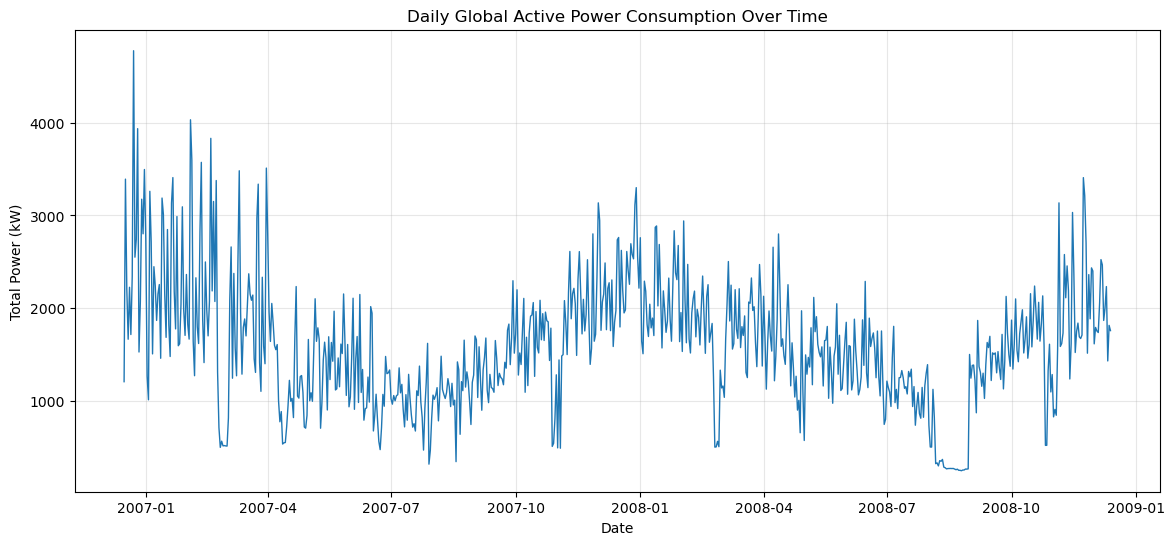

/tmp/ipykernel_4133/3435405446.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=daily_df.index.day_name(), y=daily_df['Global_active_power'],


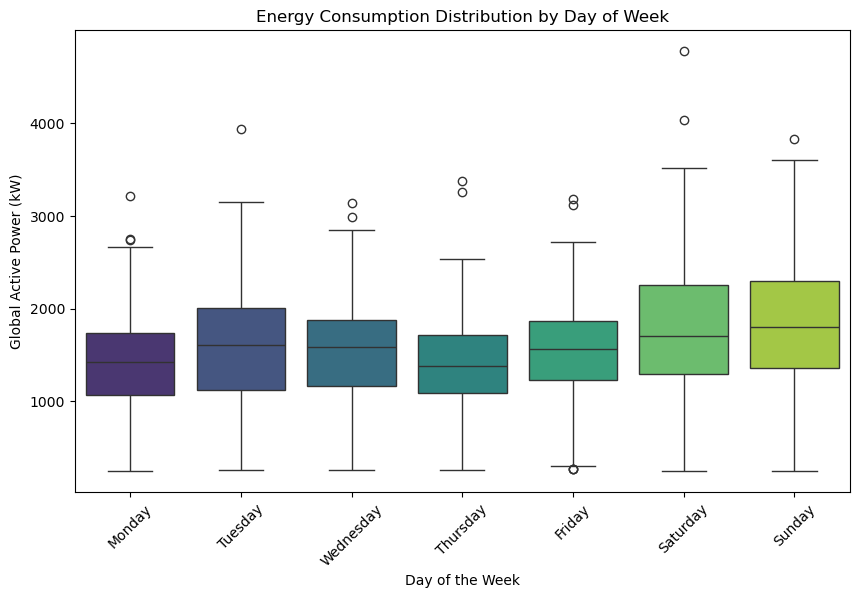

/tmp/ipykernel_4133/3435405446.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = df['Global_active_power'].resample('M').mean()


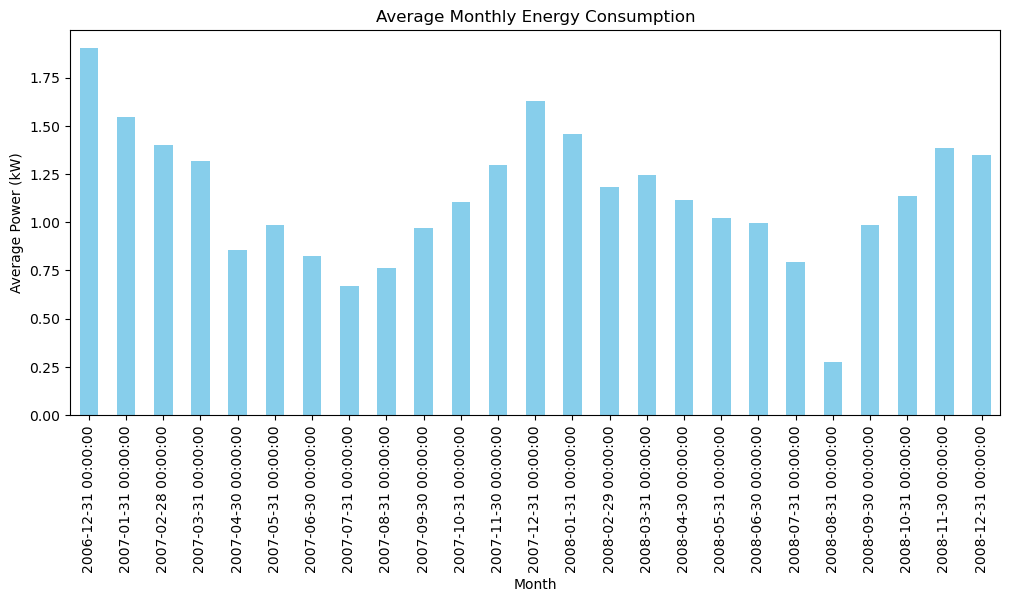

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plotting the Overall Trend
plt.figure(figsize=(14, 6))
plt.plot(daily_df['Global_active_power'], color='tab:blue', linewidth=1)
plt.title('Daily Global Active Power Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Total Power (kW)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Analyzing Day-wise Consumption Patterns
plt.figure(figsize=(10, 6))
sns.boxplot(x=daily_df.index.day_name(), y=daily_df['Global_active_power'], 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
            palette='viridis')
plt.title('Energy Consumption Distribution by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Global Active Power (kW)')
plt.xticks(rotation=45)
plt.show()

# 3. Monthly Trends to identify Seasonality
monthly_df = df['Global_active_power'].resample('M').mean()
plt.figure(figsize=(12, 5))
monthly_df.plot(kind='bar', color='skyblue')
plt.title('Average Monthly Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Average Power (kW)')
plt.show() 

# Model Building and Evaluation (ARIMA Model Building)
In this step, three distinct forecasting models are implemented: **ARIMA** (Statistical), **Prophet** (Additive/Seasonal), and **XGBoost** (Gradient Boosting). The dataset is partitioned chronologically to ensure that the models are evaluated on "future" unseen data. Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are utilized as the primary evaluation metrics to assess predictive accuracy.

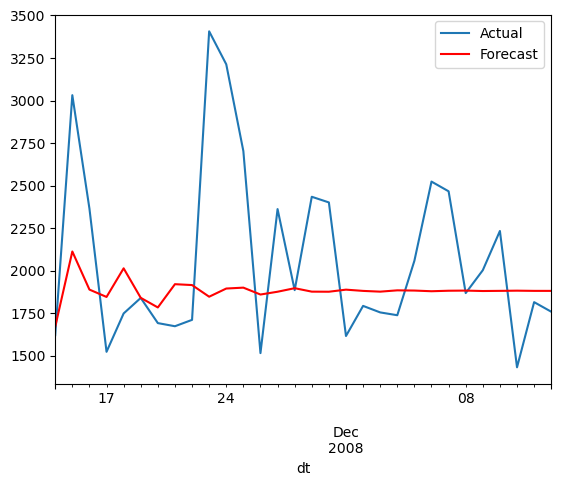

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Split and Train
train = daily_df['Global_active_power'][:-30]
model = ARIMA(train, order=(5,1,0)).fit()

# Forecast and Visualize
forecast = model.forecast(steps=30)
daily_df['Global_active_power'][-30:].plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show() 

# XGboost Model Building
A Gradient Boosting model (XGBoost) was implemented to capture non-linear patterns in the energy data. Lag features were created to provide the model with historical context for better forecasting.

In [6]:
from xgboost import XGBRegressor

# 1. Defining Features 
# Make sure daily_df is correctly formatted
daily_df['lag_1'] = daily_df['Global_active_power'].shift(1)
daily_df['day_of_week'] = daily_df.index.dayofweek
daily_df['is_weekend'] = daily_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Cleaning missing values created by shift(1)
daily_df_clean = daily_df.dropna()

# 2. Selecting Features and Target
features = ['lag_1', 'day_of_week', 'is_weekend']
X = daily_df_clean[features]
y = daily_df_clean['Global_active_power']

# 3. Training and Testing Split
X_train, X_test = X[:-30], X[-30:]
y_train, y_test = y[:-30], y[-30:]

# 4. Model Fitting
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
xgb_model.fit(X_train, y_train)

# 5. Forecast
xgb_forecast = xgb_model.predict(X_test)
print("XGBoost Model Trained Successfully!") 

XGBoost Model Trained Successfully!


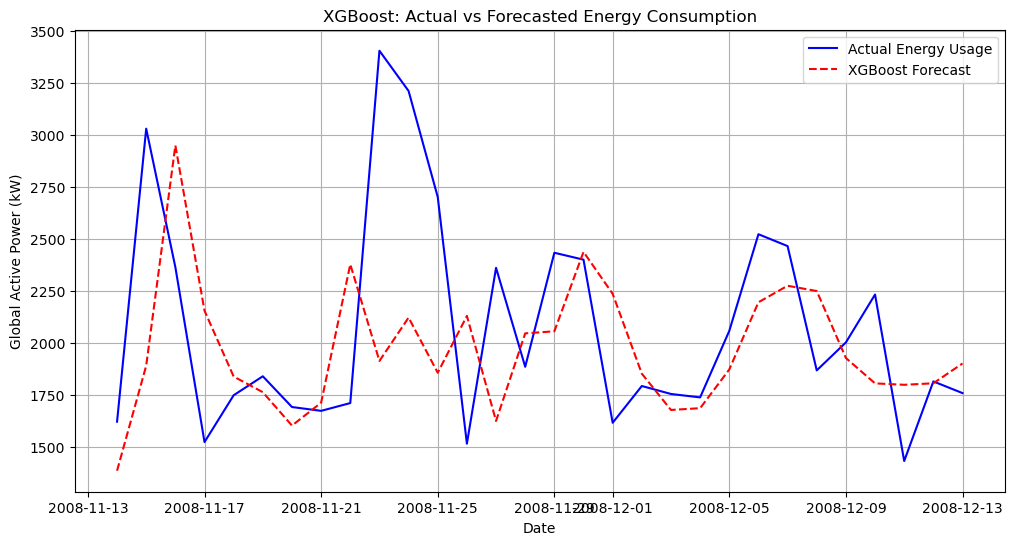

In [10]:
import matplotlib.pyplot as plt

# Graph plotting
plt.figure(figsize=(12, 6))
# Actual data (Blue line)
plt.plot(y_test.index, y_test, label='Actual Energy Usage', color='blue')
# XGBoost Forecast (Red dashed line)
plt.plot(y_test.index, xgb_forecast, label='XGBoost Forecast', color='red', linestyle='--')

plt.title('XGBoost: Actual vs Forecasted Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show() 

# Prophet Model Building
Facebook's Prophet model was utilized for its ability to handle strong daily and weekly seasonality. The model requires time series tobe formitted with columns named 'ds' and 'y'.

In [7]:
from prophet import Prophet

# Prophet needs specific column names
prophet_df = daily_df.reset_index().rename(columns={'dt': 'ds', 'Global_active_power': 'y'})

# Training on data excluding the last 30 days
model_p = Prophet()
model_p.fit(prophet_df[:-30])

# Forecasting
future = model_p.make_future_dataframe(periods=30)
forecast_p = model_p.predict(future)
prophet_preds = forecast_p['yhat'].iloc[-30:].values
print("Prophet Model Training and Forecasting Completed.") 

08:43:33 - cmdstanpy - INFO - Chain [1] start processing
08:43:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Training and Forecasting Completed.


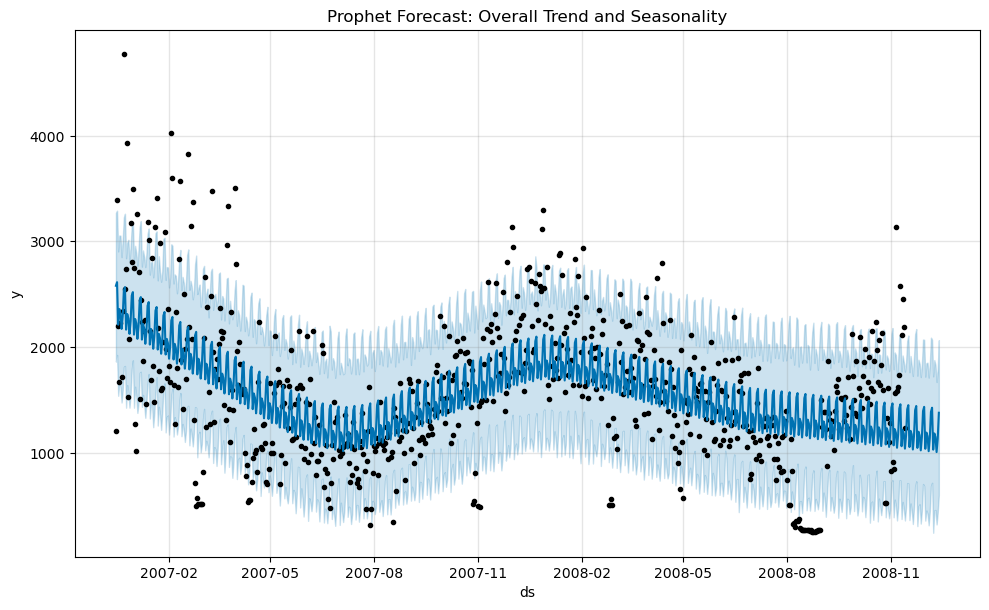

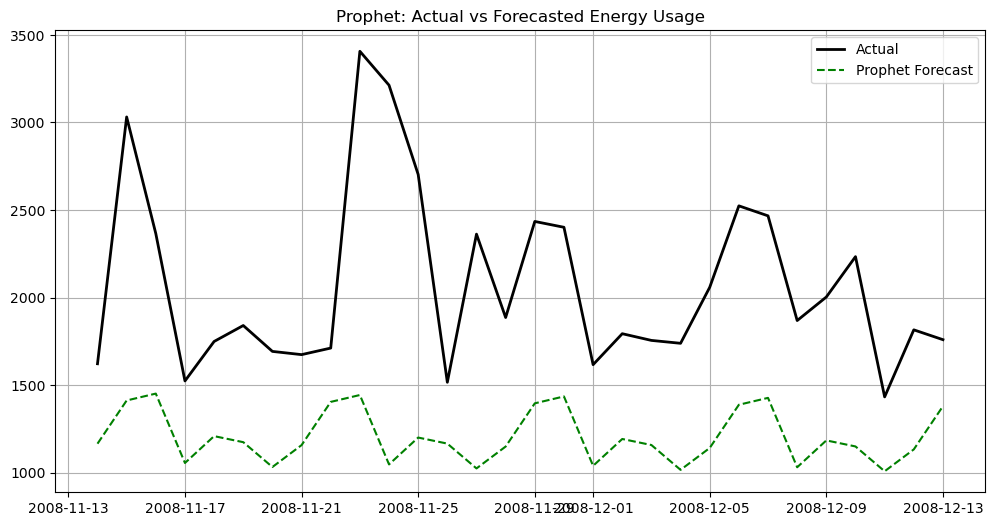

In [11]:
import matplotlib.pyplot as plt

fig1 = model_p.plot(forecast_p)
plt.title('Prophet Forecast: Overall Trend and Seasonality')
plt.show()

# 2. Actual vs Prophet Forecast (Specific 30 days comparison)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, prophet_preds, label='Prophet Forecast', color='green', linestyle='--')
plt.title('Prophet: Actual vs Forecasted Energy Usage')
plt.legend()
plt.grid(True)
plt.show() 

# Final Comparison and Evaluation
Finally, all three models (ARIMA, XGboost, and Prophet) were evaluated using MAE and RMSE. A combined visualization was plotted to compare their performance against actual data.

     Model         MAE        RMSE
0    ARIMA  377.944648  528.400578
1  XGBoost  394.277191  543.307311
2  Prophet  867.901903  980.263455


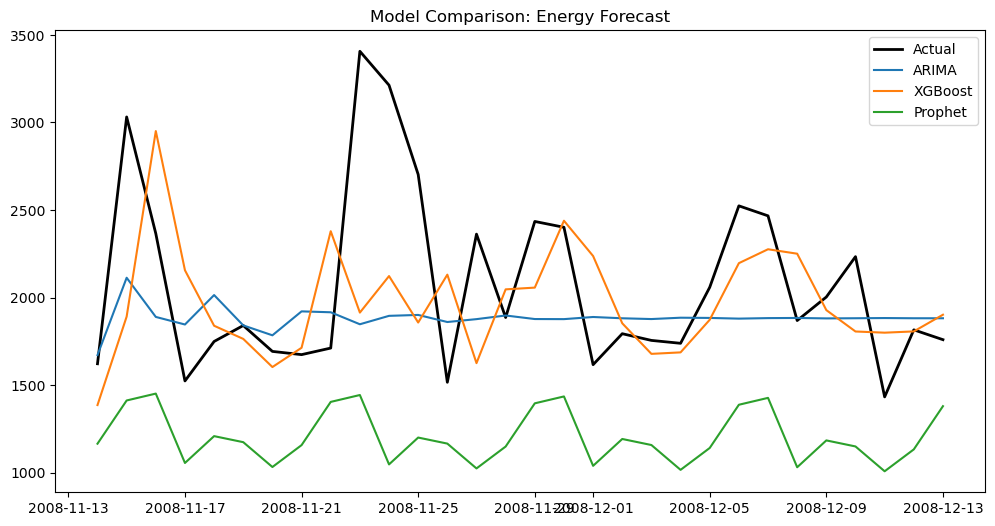

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluation Metrics Function
def get_metrics(actual, pred):
    return mean_absolute_error(actual, pred), np.sqrt(mean_squared_error(actual, pred))

# Calculating results
a_mae, a_rmse = get_metrics(y_test, forecast) # 'forecast' is your ARIMA variable
x_mae, x_rmse = get_metrics(y_test, xgb_forecast)
p_mae, p_rmse = get_metrics(y_test, prophet_preds)

# Creating Comparison Table
results = pd.DataFrame({
    'Model': ['ARIMA', 'XGBoost', 'Prophet'],
    'MAE': [a_mae, x_mae, p_mae],
    'RMSE': [a_rmse, x_rmse, p_rmse]
})

print(results)

# Combined Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, forecast, label='ARIMA')
plt.plot(y_test.index, xgb_forecast, label='XGBoost')
plt.plot(y_test.index, prophet_preds, label='Prophet')
plt.title('Model Comparison: Energy Forecast')
plt.legend()
plt.show() 

# Final Conclusion with Insights
.The performance comparison shows which model best captures the daily fluctuations in energy usage.
While ARIMA is effective for trend analysis, XGBoost and Prophet often handle seasonality better.
These insights are valuable for short-term household energy planning and optimization.